## RİDGE REGRESYONU


In [2]:
# Lassoya göre az ceza verir çünkü L2 tekniğini kllanır.
# alpha L2 hipermarametresidiir.default 1 dir.
# kütüphaneleri indirelim.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seabornInstance
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline
import matplotlib 
matplotlib.rcParams.update({"font.size":12})
from sklearn.linear_model import Ridge


In [3]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [4]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
#Liner regresyon modeli (bunu Ridge ile kıyaslamak için kullanacağız.)
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [6]:
#Ridge ile eğitim verisin eğitelim
#alpha az olursa linere benzer çok olursa ceza artar
#farkı anlamak için iki uç değer seçiyoruz.
rr=Ridge(alpha=0.01)
rr.fit(x_train,y_train)

rr100=Ridge(alpha=100)
rr100.fit(x_train,y_train)


Ridge(alpha=100)

In [8]:
#Lineer modelin R2  scorlaını hesaplayalım.
lr_train_score=lr.score(x_train,y_train)
lr_test_score=lr.score(x_test,y_test)

#Ridge  0.01 R2 değerleri
ridge_train_score=rr.score(x_train,y_train)
ridge_test_score=rr.score(x_test,y_test)

#Ridge 100 R2 değerleri
ridge100_train_score=rr100.score(x_train,y_train)
ridge100_test_score=rr100.score(x_test,y_test)


In [13]:
# R2 sonuçları
print("Liner Regresyon egitim seti R2 degeri: ",round(lr_train_score,4))
print("Liner Regresyon test seti R2 degeri:",round(lr_test_score,4))
print("Ridge 0.01 Regresyon egitim seti R2 degeri:",round(ridge_train_score,4))
print("Ridge 0.01 Regresyon test seti R2 degeri:",round(ridge_test_score,4))
print("Ridge 100 Regresyon egitim seti R2 degeri:",round(ridge100_train_score,4))
print("Ridge1 100 Regresyon test seti R2 degeri:",round(ridge100_test_score,4))


Liner Regresyon egitim seti R2 degeri:  0.7337
Liner Regresyon test seti R2 degeri: 0.6987
Ridge 0.01 Regresyon egitim seti R2 degeri: 0.7337
Ridge 0.01 Regresyon test seti R2 degeri: 0.6986
Ridge 100 Regresyon egitim seti R2 degeri: 0.6682
Ridge1 100 Regresyon test seti R2 degeri: 0.5584


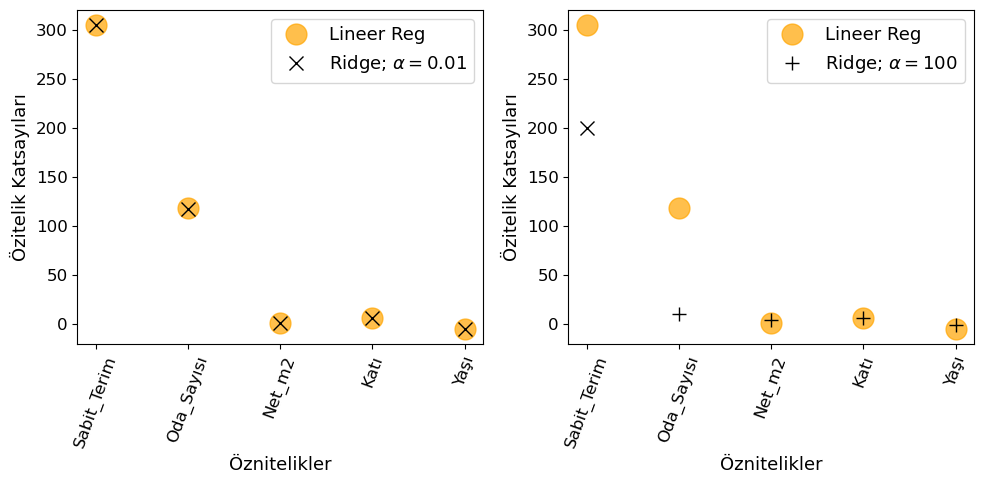

In [16]:
# Grafikleri karşılaştırma
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot((1,2,3,4),lr.coef_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange",label="Lineer Reg",zorder=2)
plt.plot((1,2,3,4),rr.coef_,alpha=1,linestyle="none",marker="x",markersize=10,color="black",label=r"Ridge; $\alpha =0.01$",zorder=7)
plt.plot(0,lr.intercept_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange")
plt.plot(0,rr.intercept_,alpha=1,linestyle="none",marker="x",markersize=10,color="black")

plt.xticks([0,1,2,3,4],("Sabit_Terim","Oda_Sayısı","Net_m2","Katı","Yaşı"),rotation=70)
plt.xlabel("Öznitelikler",fontsize=13)
plt.ylabel("Özitelik Katsayıları",fontsize=13)
plt.legend(fontsize=13,loc="upper right")
plt.subplot(1,2,2)

plt.plot((1,2,3,4),lr.coef_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange",label="Lineer Reg",zorder=2)
plt.plot((1,2,3,4),rr100.coef_,alpha=1,linestyle="none",marker="+",markersize=10,color="black",label=r"Ridge; $\alpha =100$")
plt.plot(0,lr.intercept_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange")
plt.plot(0,rr100.intercept_,alpha=1,linestyle="none",marker="x",markersize=10,color="black")

plt.xticks([0,1,2,3,4],("Sabit_Terim","Oda_Sayısı","Net_m2","Katı","Yaşı"),rotation=70)
plt.xlabel("Öznitelikler",fontsize=13)
plt.ylabel("Özitelik Katsayıları",fontsize=13)
plt.legend(fontsize=13,loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
#Ridge 100 için parametre tahmini:
print(rr100.intercept_)
print()
rr100_katsayilar=pd.DataFrame(rr100.coef_,x.columns,columns=["Ridge 100 öznitelik sayıları"])

print(rr100_katsayilar)

200.69224429331803

            Ridge 100 öznitelik sayıları
Oda_Sayısı                     11.104787
Net_m2                          4.644286
Katı                            7.093988
Yaşı                           -0.376032


In [22]:
# kıyaslamak için liner reg tahminine bakalım:
print(lr.intercept_)
print()
lr_katsayilar=pd.DataFrame(rr100.coef_,x.columns,columns=["Liner Reg öznitelik sayıları"])

print(lr_katsayilar)


305.16258952877524

            Liner Reg öznitelik sayıları
Oda_Sayısı                     11.104787
Net_m2                          4.644286
Katı                            7.093988
Yaşı                           -0.376032
